In [1]:
import biom
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import biom_to_csv as btc

In [2]:
#function x sample dataset
func_table = biom.load_table('functional_table_final.biom')
df_func = func_table.to_dataframe(dense=True)
X_sf = df_func.T

In [3]:
#describe dataset
funzioni_per_campione = (X_sf > 0).sum(axis=1)
print('Funzioni per campione:')
print(funzioni_per_campione.describe())

campioni_per_funzione = (X_sf > 0).sum(axis=0)
print('\nFunzioni più comuni:')
print(campioni_per_funzione.sort_values(ascending=False).head(20))

X_sf_clean = X_sf.loc[:, (X_sf > 0).any(axis=0)]
print(f'\nFunzioni con almeno 1 presenza: {X_sf_clean.shape[1]} su {X_sf.shape[1]}')

Funzioni per campione:
count    17483.000000
mean        29.832981
std         15.996783
min          0.000000
25%         16.000000
50%         29.000000
75%         43.000000
max         76.000000
dtype: float64

Funzioni più comuni:
chemoheterotrophy                17389
aerobic_chemoheterotrophy        17064
fermentation                     16846
nitrate_reduction                15462
animal_parasites_or_symbionts    14623
chloroplasts                     12747
nitrogen_respiration             12076
methylotrophy                    12063
phototrophy                      11959
intracellular_parasites          11951
nitrate_respiration              11925
human_associated                 11813
methanol_oxidation               11396
human_pathogens_all              11261
ureolysis                        11136
photoheterotrophy                10570
nitrite_respiration              10550
aromatic_compound_degradation    10425
hydrocarbon_degradation          10148
photoautotrophy        

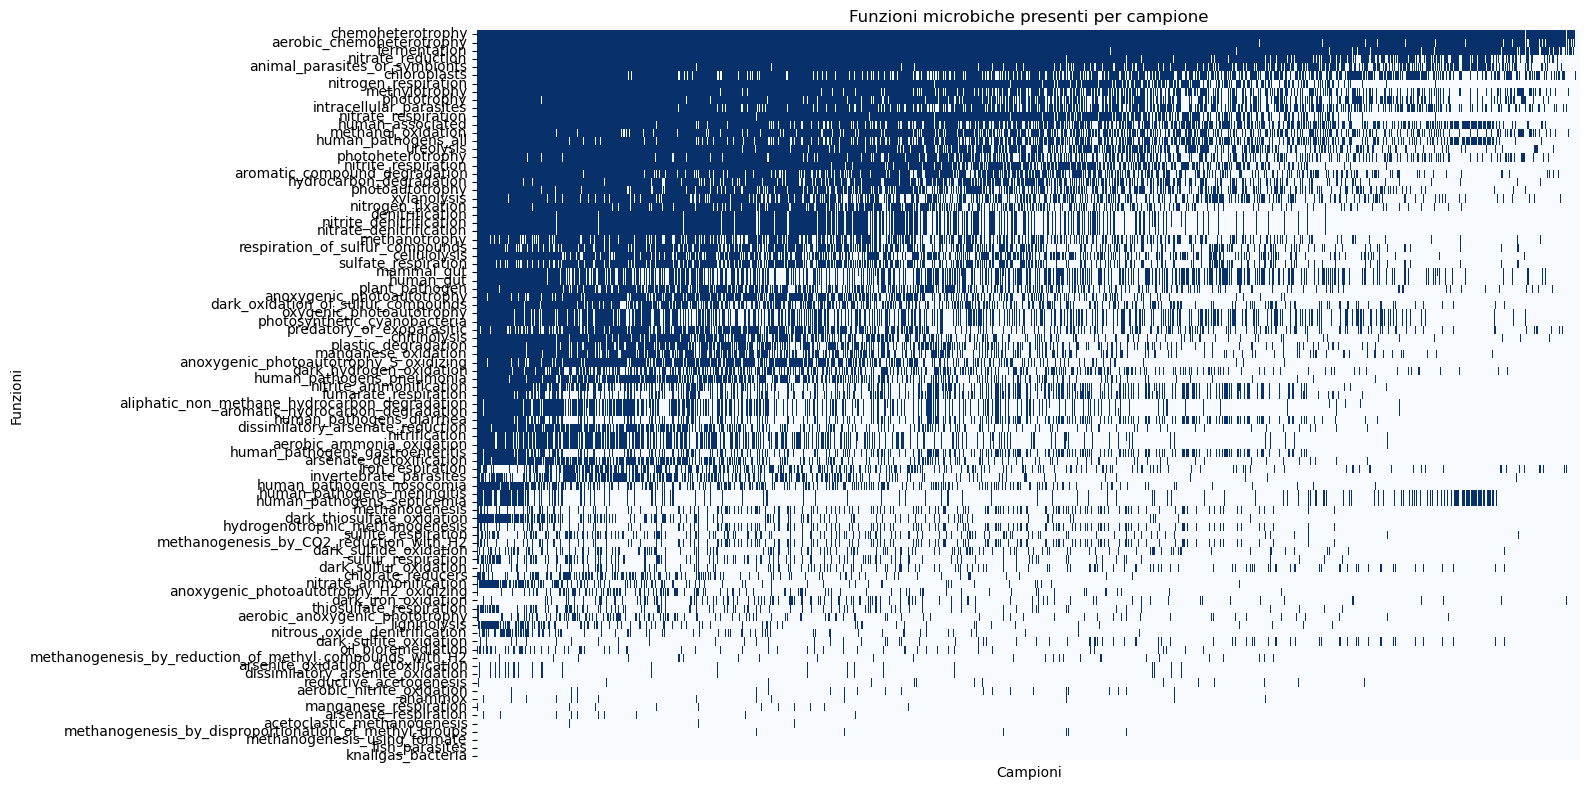

In [4]:
X_sf_bin = (X_sf_clean > 0).astype(int)

funz_order = X_sf_bin.sum(axis=0).sort_values(ascending=False).index
camp_order = X_sf_bin.sum(axis=1).sort_values(ascending=False).index

X_sf_sorted = X_sf_bin.loc[camp_order, funz_order]

plt.figure(figsize=(16, 8))
sns.heatmap(X_sf_sorted.T, 
            cmap='Blues',
            cbar=False,
            xticklabels=False,
            yticklabels=True)
plt.title('Funzioni microbiche presenti per campione')
plt.xlabel('Campioni')
plt.ylabel('Funzioni')
plt.tight_layout()
#plt.savefig('functional_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlazione entropia funzionale entropia tassonomica

In [5]:
#calculate bare entropies function entropy and sample entropy (functions)
Hf, Hsf = btc.entropy(X_sf)
print('Entropia funzioni')
print(Hf[:5])
print('Entropia sample')
print(Hsf[:5])

Entropia funzioni
methanotrophy                                            7.159992
acetoclastic_methanogenesis                              4.345809
methanogenesis_by_disproportionation_of_methyl_groups    3.339695
methanogenesis_using_formate                             2.031759
methanogenesis_by_CO2_reduction_with_H2                  6.922286
dtype: float64
Entropia sample
2229.S2.N22.EH1.Thomas.CMB.Seaweed.lane6.NoIndex.L006     1.281492
1883.2008.034.Crump.Artic.LTREB.main.lane2.NoIndex        1.449858
864.OTC.R.6.2009a.lane2.NoIndex                           2.622639
1883.2005.031.Crump.Artic.LTREB.main.lane1.NoIndex        1.603523
2229.W1.N2.4.HP4.Thomas.CMB.Seaweed.lane5.NoIndex.L005    0.555689
dtype: float64


In [6]:
X_sb   = btc.biom_to_csv_phylum('emp_deblur_150bp.release1.biom')

In [7]:
#calculate bare entropies phyla entropy and sample entropy (taxonomic)
Hp, Hsp = btc.entropy(X_sb)
print('Entropia phyla')
print(Hp[:5])
print('Entropia sample')
print(Hsp[:5])

Entropia phyla
p__Proteobacteria    9.070891
p__Cyanobacteria     7.571775
p__Bacteroidetes     8.996929
p__TM6               7.680503
p__Firmicutes        8.248840
dtype: float64
Entropia sample
2229.S2.N22.EH1.Thomas.CMB.Seaweed.lane6.NoIndex.L006     1.275213
1883.2008.034.Crump.Artic.LTREB.main.lane2.NoIndex        1.035694
864.OTC.R.6.2009a.lane2.NoIndex                           2.038324
1883.2005.031.Crump.Artic.LTREB.main.lane1.NoIndex        1.389329
2229.W1.N2.4.HP4.Thomas.CMB.Seaweed.lane5.NoIndex.L005    1.083908
dtype: float64


In [8]:
df_scatter = pd.DataFrame({
    'H_phylum': Hsp,
    'H_funzioni': Hsf
}).dropna()

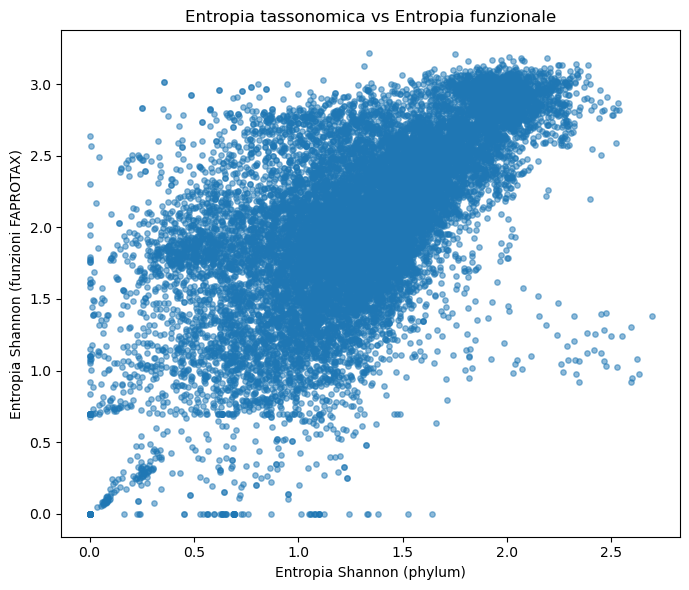

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(df_scatter['H_phylum'], df_scatter['H_funzioni'],
           alpha=0.5, s=15)

ax.set_xlabel('Entropia Shannon (phylum)')
ax.set_ylabel('Entropia Shannon (funzioni FAPROTAX)')
ax.set_title('Entropia tassonomica vs Entropia funzionale')

plt.tight_layout()
#plt.savefig('entropia_phylum_vs_funzioni.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
#align metadata to dataset (sample x phyla)
meta = pd.read_csv('emp_qiime_mapping_release1.tsv', sep='\t', index_col=0, low_memory=False)
meta_filtered = meta.loc[meta.index.isin(X_sb.index)]
meta_aligned = meta_filtered.reindex(X_sb.index)

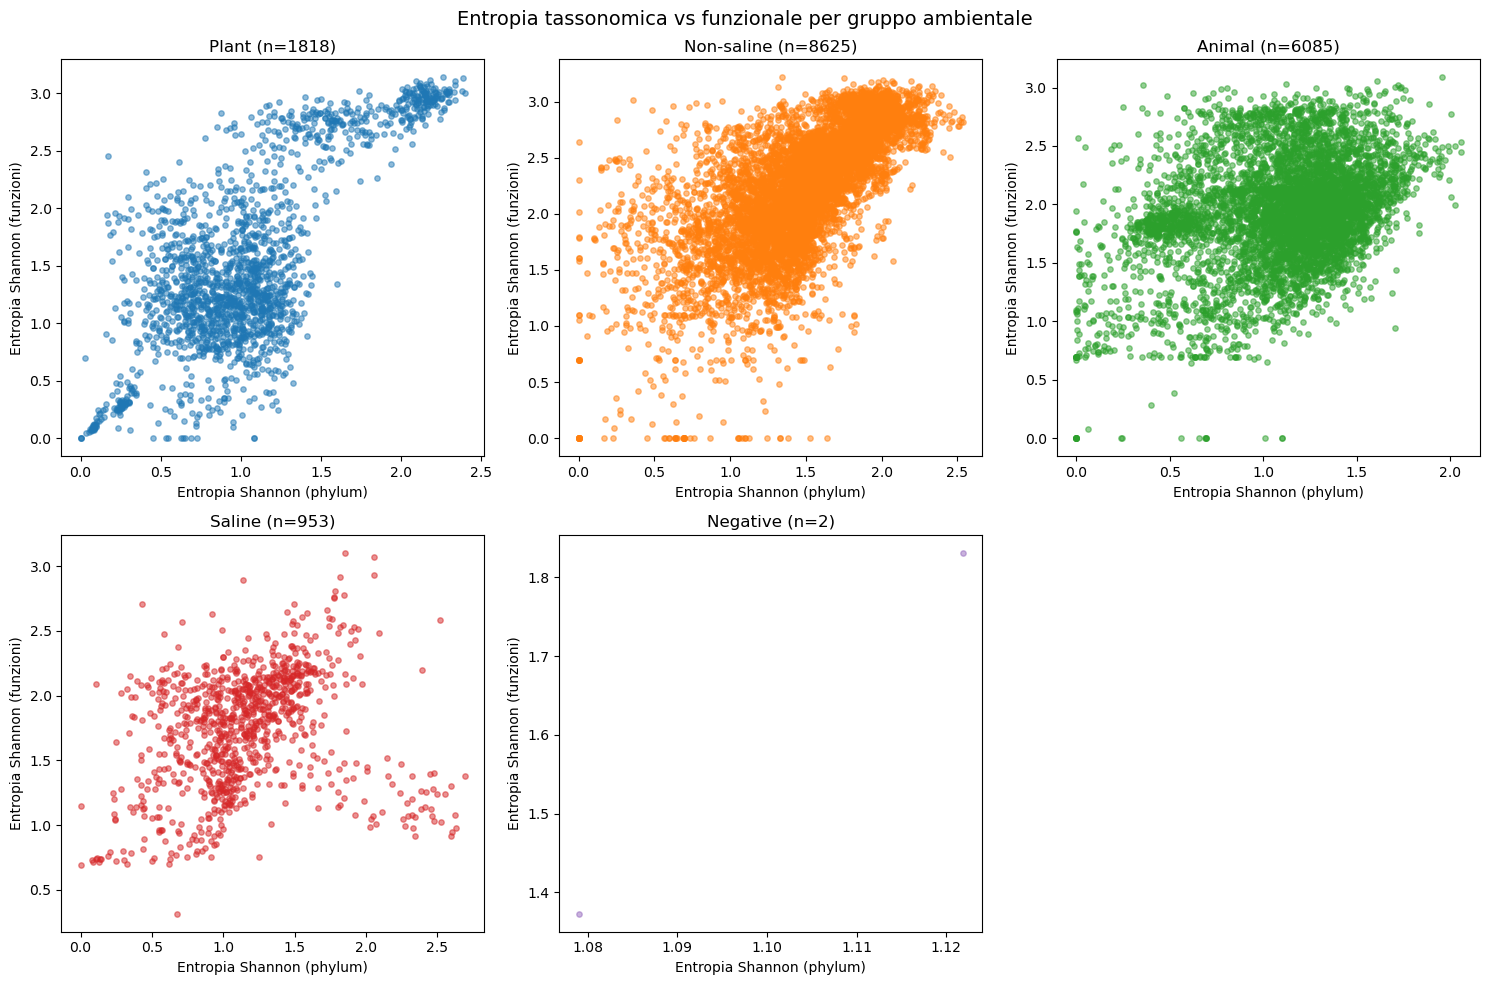

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

gruppi = meta_aligned.loc[df_scatter.index, 'empo_2'].dropna().unique()
colors = plt.cm.tab10(range(len(gruppi)))

for idx, (gruppo, color) in enumerate(zip(gruppi, colors)):
    
    ids_gruppo = meta_aligned[meta_aligned['empo_2'] == gruppo].index
    subset = df_scatter.loc[df_scatter.index.isin(ids_gruppo)]
    
    axes[idx].scatter(subset['H_phylum'], subset['H_funzioni'],
                      c=[color], alpha=0.5, s=15)
    
    axes[idx].set_xlabel('Entropia Shannon (phylum)')
    axes[idx].set_ylabel('Entropia Shannon (funzioni)')
    axes[idx].set_title(f'{gruppo} (n={len(subset)})')

for idx in range(len(gruppi), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Entropia tassonomica vs funzionale per gruppo ambientale', fontsize=14)
plt.tight_layout()
#plt.savefig('entropia_per_gruppo.png', dpi=150, bbox_inches='tight')
plt.show()

##### in questi grafici le entropie sono state calcolate su tutto il dataset non per singolo gruppo

In [12]:
#align metadata to dataset (sample x function)
meta_filtered_f = meta.loc[meta.index.isin(X_sf.index)]
meta_aligned_f = meta_filtered_f.reindex(X_sf.index)

In [13]:
gruppi = {}
for gruppo in meta_aligned['empo_2'].unique():
    mask = meta_aligned['empo_2'] == gruppo
    gruppi[gruppo] = X_sb[mask]
    print(f"{gruppo}: {gruppi[gruppo].shape}")
gruppi.pop("Negative")

Plant: (1818, 81)
Non-saline: (8625, 81)
Animal: (6085, 81)
Saline: (953, 81)
Negative: (2, 81)


,p__Proteobacteria,p__Cyanobacteria,p__Bacteroidetes,p__TM6,p__Firmicutes,p__Chloroflexi,p__Unknown,p__Armatimonadetes,p__Gemmatimonadetes,p__OP3,...,p__OP1,p__TPD-58,p__AncK6,p__H-178,p__Caldiserica,p__OC31,p__Aquificae,p__OctSpA1-106,p__VHS-B3-43,p__Thermotogae
1883.empty.well.2.Crump.Artic.LTREB.main.lane4.NoIndex,3.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1883.vacant.Crump.Artic.LTREB.main.lane1.NoIndex,159.0,0.0,36.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
gruppi_f = {}
for gruppo in meta_aligned_f['empo_2'].unique():
    mask = meta_aligned_f['empo_2'] == gruppo
    gruppi_f[gruppo] = X_sf[mask]
    print(f"{gruppo}: {gruppi_f[gruppo].shape}")
gruppi_f.pop("Negative")

Plant: (1818, 92)
Non-saline: (8625, 92)
Animal: (6085, 92)
Saline: (953, 92)
Negative: (2, 92)


,methanotrophy,acetoclastic_methanogenesis,methanogenesis_by_disproportionation_of_methyl_groups,methanogenesis_using_formate,methanogenesis_by_CO2_reduction_with_H2,methanogenesis_by_reduction_of_methyl_compounds_with_H2,hydrogenotrophic_methanogenesis,methanogenesis,methanol_oxidation,methylotrophy,...,anoxygenic_photoautotrophy,oxygenic_photoautotrophy,photoautotrophy,aerobic_anoxygenic_phototrophy,photoheterotrophy,phototrophy,plastic_degradation,ureolysis,reductive_acetogenesis,chemoheterotrophy
1883.empty.well.2.Crump.Artic.LTREB.main.lane4.NoIndex,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
1883.vacant.Crump.Artic.LTREB.main.lane1.NoIndex,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0,49.0,...,0.0,0.0,0.0,0.0,8.0,8.0,0.0,0.0,0.0,66.0


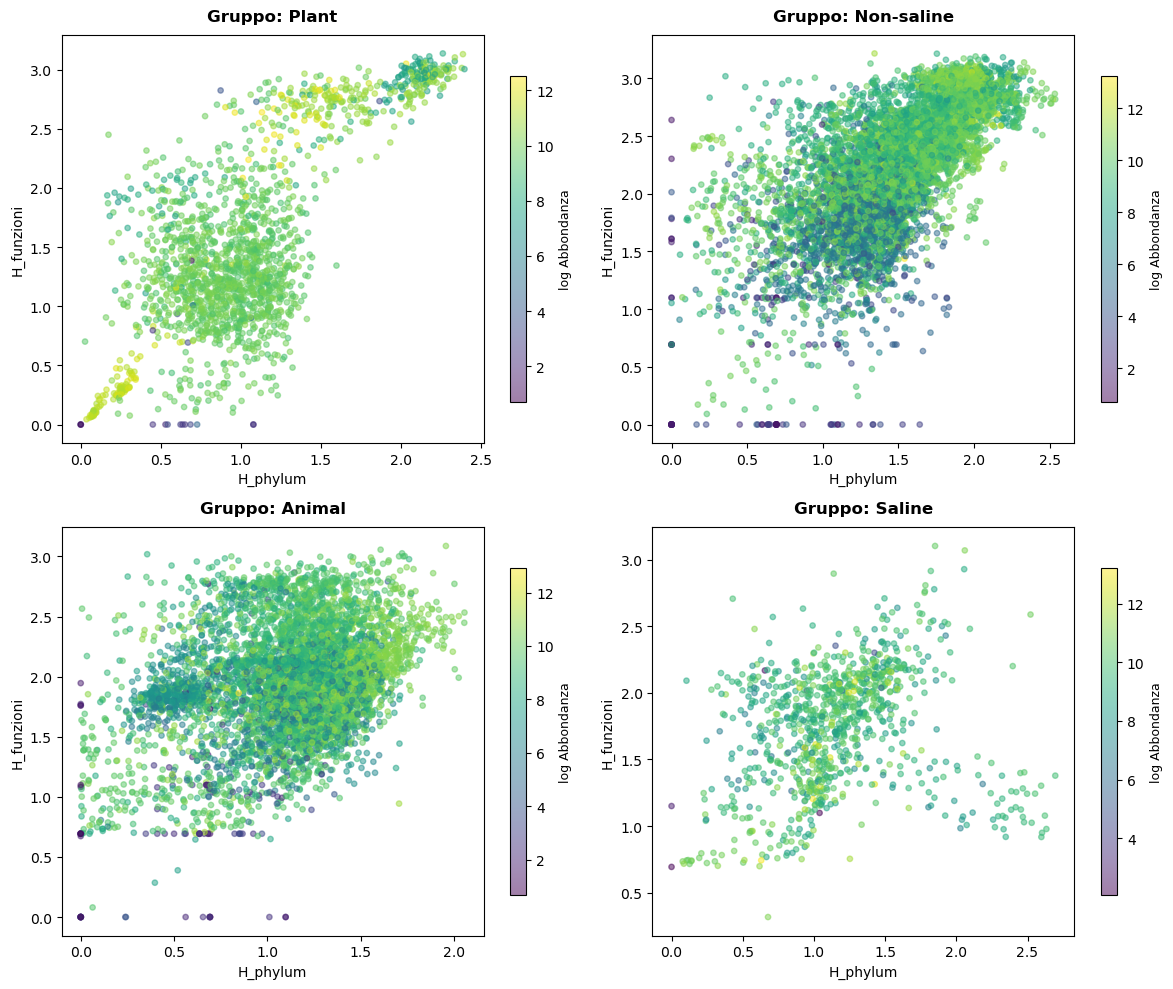

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, gruppo in enumerate(gruppi.keys()):
    ax = axes[i]

    Hpf, Hsf = btc.entropy(gruppi_f[gruppo])
    Hp, Hs = btc.entropy(gruppi[gruppo])
    abbondanza = np.log(gruppi[gruppo].sum(axis=1))
    
    df_scatter_sing = pd.DataFrame({
        'H_phylum': Hs,
        'H_funzioni': Hsf,
        'abbondanza' : abbondanza
    }).dropna()

    sc = ax.scatter(df_scatter_sing['H_phylum'], df_scatter_sing['H_funzioni'], alpha=0.5, s=15, c=df_scatter_sing['abbondanza'], cmap='viridis')

    #ax.set_xscale('log')
    #ax.set_yscale('log')

    ax.set_xlabel('H_phylum', fontsize=10)
    ax.set_ylabel('H_funzioni', fontsize=10)
    ax.set_title(f'Gruppo: {gruppo}', fontsize=12, fontweight='bold', pad=10)

    cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
    cbar.set_label('log Abbondanza', fontsize=9)

plt.tight_layout()
plt.show()

##### in questi grafici le entropie sono state calcolate rispetto al singolo gruppo e non sull'intero dataset